In [8]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import itertools as it
import knee.rdp as rdp
import knee.kneedle as kneedle
from scipy.special import comb

import time

from controlled_zeros import *
from data_generation import *
from weight_computer import *

from castle.common import GraphDAG, independence_tests
from castle.metrics import MetricsDAG
from castle.algorithms import PC

import matplotlib
font = {'size'   : 11}
matplotlib.rc('font', **font)

In [3]:
def condition(node_list, arr ,m):
    H = nx.DiGraph()
    H.add_nodes_from(node_list)
    H.add_edges_from(np.unique(arr[m:],axis=1))
    return nx.is_connected(H.to_undirected())

def binary_search(node_list, arr):
    '''arr - sorted array'''
    L=0
    R=len(arr)-1
    while L<=R:
        if L==R:
            return L
        
        m = int((L+R)/2)+1
        if not condition(node_list, arr, m): #is it not connected?
            R = m-1
        else:
            L = m
    return "fail"

def triangulation(df, edge_list, thres, states):
    DAG_w2 = nx.DiGraph()
    DAG_w2.add_nodes_from(df.columns)
    DAG_w2.add_edges_from(edge_list)
    
    for b in np.array(DAG_w2.nodes)[np.array(DAG_w2.in_degree)[:,1].astype("int")>1]:
        parents = np.array(list(DAG_w2.in_edges(b)))[:,0]
        
        for a in parents: #a-> b <-u (test a->b; b=node)
            if (a,b) not in DAG_w2.edges: #was it already removed?
                continue
            #Note: it.permutations(parents,2) can't be used in conjuction with the last break since that will cause the cycle to skip triangles for different a's.
            for c in parents[parents!=a]:
                #print(b,a,parents[parents!=a])
                survives=False

                for st_varB,st_varA,st_varC in it.product(*[states[b],states[a],states[c]]):
                    PC = (df[c]==st_varC).sum()
                    PAC= ((df[a]==st_varA)&(df[c]==st_varC)).sum()
                    PBC= ((df[b]==st_varB)&(df[c]==st_varC)).sum()
                    PABC= ((df[b]==st_varB)&(df[a]==st_varA)&(df[c]==st_varC)).sum()
                    if PAC!=0 and PAC!=PC: #conditioned to c
                        if np.abs(PABC*PC-PAC*PBC)/(PAC*(PC-PAC)) > thres:
                            survives=True
                            break

                if not survives:
                    DAG_w2.remove_edge(a,b)
                    #if (DAG_w2.out_degree(a) == 0):
                    #    if order[a]<order[c]:
                    #        DAG_w2.add_edge(a,c)
                    #    if order[c]<order[a]:
                    #        DAG_w2.add_edge(c,a)

                    break
    return DAG_w2

def triangulation2(data, node_list, edge_list, thres):
    key = {df.columns[i]:i for i in range(len(df.columns))}
    DAG_w2 = nx.DiGraph()
    DAG_w2.add_nodes_from(node_list)
    DAG_w2.add_edges_from(edge_list)
    
    for b in np.array(DAG_w2.nodes)[np.array(DAG_w2.in_degree)[:,1].astype("int")>1]:
        parents = np.array(list(DAG_w2.in_edges(b)))[:,0]
        
        for a in parents: #a-> b <-u (test a->b; b=node)
            if (a,b) not in DAG_w2.edges: #was it already removed?
                continue
            #Note: it.permutations(parents,2) can't be used in conjuction with the last break since that will cause the cycle to skip triangles for different a's.
            for c in parents[parents!=a]:
                #print(b,a,parents[parents!=a])
                if independence_tests.CITest.fisherz_test(data,key[a],key[b],[key[c]])[2] > thres: #does not survive
                    DAG_w2.remove_edge(a,b)
                    break
                    
    return DAG_w2

In [83]:
data=np.zeros([10,30])

for i in range(10):
    n_nodes, density, orphans = 200, 2, 0.01
    DAGt = controlled_zeros(n_nodes, density, orphans)
    DAGt = nx.relabel_nodes(DAGt,{node:str(node) for node in DAGt.nodes})
    
    states = stater(DAGt, min_states=2, max_states=4)
    states_prob = probabiliter_controlled(DAGt, states)
    df = generator(DAGt, states, states_prob, 10000)
    order = {node:int(node) for node in DAGt.nodes}
    
    data[i,0] = n_nodes
    data[i,1] = np.mean((np.array(DAGt.in_degree)[:,1]).astype("int"))

    print(i)
    
    #Change data format for PC Algorithm
    a = np.zeros(np.shape(df))
    k=0
    for col in df:
        #print(df[col])
        j=0
        for st in states[col]:
            a[:,k][np.where(df[col]==st)]=j
            j+=1
        k+=1
    true_matrix=nx.adjacency_matrix(DAGt,nodelist=df.columns).toarray()

    #PC Algorithm
    ti = time.process_time_ns()
    pc = PC(alpha=0.05)
    pc.learn(a)
    data[i,2] = (time.process_time_ns() - ti)*1e-9 #time in seconds
    FN = int(np.sum((true_matrix-pc.causal_matrix)>0)) #False Negatives
    FP = int(np.sum((true_matrix-pc.causal_matrix)<0)) #False Positives
    TP = len(DAGt.edges) - FN #True Positives = P - FN
    TN = (comb(len(df.columns),2).astype(int) - len(DAGt.edges)) - FP #True Negatives = N - FP
    data[i,3] = FP/(comb(len(df.columns),2).astype(int) - len(DAGt.edges)) #FPR = FP/N
    data[i,4] = FN/len(DAGt.edges) #FNR = FN/P
    data[i,5] = (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) #MCC

    #Connected with Fisher
    ti = time.process_time_ns()
    fish_vals = [independence_tests.CITest.fisherz_test(a,x,y,[])[2] for x,y in it.permutations(range(len(a[0])),2)]
    fish_vars = [(x,y) for x,y in it.permutations(list(df.columns),2)]

    unique_edges, unique_vals = np.array(fish_vars)[np.argsort(fish_vals)], np.sort(fish_vals)
    unique_edges = np.flip(unique_edges)
    unique_vals = np.flip(unique_vals)

    ##Threshold in first step
    for j in np.unique(unique_vals,return_index=True)[1]:
        H = nx.Graph()
        H.add_nodes_from(df.columns)
        H.add_edges_from(unique_edges[j:])
        if nx.is_connected(H):
            m = j
            break
    del H
    thres = unique_vals[m]
    data[i,6] = m
    data[i,7] = thres

    ##Second Step
    DAG_w2 = triangulation2(a, df.columns, unique_edges[m:], thres)
    
    data[i,8] = (time.process_time_ns() - ti)*1e-9 #time in seconds
    FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
    FP = len(DAG_w2.edges-DAGt.edges) #False Positives
    TP = len(DAGt.edges) - FN #True Positives = P - FN
    TN = (comb(len(df.columns),2).astype(int) - len(DAGt.edges)) - FP #True Negatives = N - FP
    data[i,9] = FP/(comb(len(df.columns),2).astype(int) - len(DAGt.edges)) #FPR = FP/N
    data[i,10] = FN/len(DAGt.edges) #FNR = FN/P
    data[i,11] = (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) #MCC
    
    #Knee with Fisher
    ti = time.process_time_ns()
    
    fish_vals = [independence_tests.CITest.fisherz_test(a,x,y,[])[2] for x,y in it.permutations(range(len(a[0])),2)]
    fish_vars = [(x,y) for x,y in it.permutations(list(df.columns),2)]
    
    unique_edges, unique_vals = np.array(fish_vars)[np.argsort(fish_vals)], np.sort(fish_vals)
    unique_edges = np.flip(unique_edges)
    unique_vals = np.flip(unique_vals)

    ##Threshold in first step
    gcc_nodes=np.zeros(len(unique_edges))
    for j in range(len(unique_edges)):
        H = nx.Graph()
        H.add_edges_from(unique_edges[j:])
        gcc_nodes[j] = len(sorted(nx.connected_components(H), key=len, reverse=True)[0])
    del H
    m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
    thres = unique_vals[m]
    data[i,12] = m
    data[i,13] = thres

    ##Second Step
    DAG_w2 = triangulation2(a, df.columns, unique_edges[m:], thres)
    
    data[i,14] = (time.process_time_ns() - ti)*1e-9 #time in seconds
    FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
    FP = len(DAG_w2.edges-DAGt.edges) #False Positives
    TP = len(DAGt.edges) - FN #True Positives = P - FN
    TN = (comb(len(df.columns),2).astype(int) - len(DAGt.edges)) - FP #True Negatives = N - FP
    data[i,15] = FP/(comb(len(df.columns),2).astype(int) - len(DAGt.edges)) #FPR = FP/N
    data[i,16] = FN/len(DAGt.edges) #FNR = FN/P
    data[i,17] = (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) #MCC

    #Connected with NI
    ti = time.process_time_ns()

    weight_num_writer(df, states, order)
    wn_var = np.array(weight_var_importer('weights_num.txt'))
    wn_val = np.array(weight_val_importer('weights_num.txt'))
    
    unique_edges = np.unique(wn_var[:,:2],axis=0)
    unique_vals = np.zeros(len(unique_edges))
    for j in range(len(unique_edges)):
        pair = unique_edges[j]
        unique_vals[j] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
    unique_vals=np.abs(unique_vals)
    unique_edges, unique_vals = unique_edges[np.argsort(unique_vals)], np.sort(unique_vals)

    ##Threshold in first step
    m=binary_search(list(states), unique_edges)
    thres = unique_vals[m]
    data[i,18] = m
    data[i,19] = thres

    ##Second Step
    DAG_w2 = triangulation(df, unique_edges[m:], thres, states)

    data[i,20] = (time.process_time_ns() - ti)*1e-9 #time in seconds
    FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
    FP = len(DAG_w2.edges-DAGt.edges) #False Positives
    TP = len(DAGt.edges) - FN #True Positives = P - FN
    TN = (comb(len(df.columns),2).astype(int) - len(DAGt.edges)) - FP #True Negatives = N - FP
    data[i,21] = FP/(comb(len(df.columns),2).astype(int) - len(DAGt.edges)) #FPR = FP/N
    data[i,22] = FN/len(DAGt.edges) #FNR = FN/P
    data[i,23] = (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) #MCC

    #Knee with NI
    ti = time.process_time_ns()

    weight_num_writer(df, states, order)
    wn_var = np.array(weight_var_importer('weights_num.txt'))
    wn_val = np.array(weight_val_importer('weights_num.txt'))
        
    unique_edges = np.unique(wn_var[:,:2],axis=0)
    unique_vals = np.zeros(len(unique_edges))
    for j in range(len(unique_edges)):
        pair = unique_edges[j]
        unique_vals[j] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
    unique_vals=np.abs(unique_vals)
    unique_edges, unique_vals = unique_edges[np.argsort(unique_vals)], np.sort(unique_vals)
    
    ##Threshold in first step
    gcc_nodes=np.zeros(len(unique_edges))
    for j in range(len(unique_edges)):
        H = nx.Graph()
        H.add_edges_from(unique_edges[j:])
        gcc_nodes[j] = len(sorted(nx.connected_components(H), key=len, reverse=True)[0])
    del H
    m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
    thres = unique_vals[m]
    data[i,24] = m
    data[i,25] = thres

    ##Second Step
    DAG_w2 = triangulation(df, unique_edges[m:], thres, states)

    data[i,26] = (time.process_time_ns() - ti)*1e-9 #time in seconds
    FN = len(DAGt.edges-DAG_w2.edges) #False Negatives
    FP = len(DAG_w2.edges-DAGt.edges) #False Positives
    TP = len(DAGt.edges) - FN #True Positives = P - FN
    TN = (comb(len(df.columns),2).astype(int) - len(DAGt.edges)) - FP #True Negatives = N - FP
    data[i,27] = FP/(comb(len(df.columns),2).astype(int) - len(DAGt.edges)) #FPR = FP/N
    data[i,28] = FN/len(DAGt.edges) #FNR = FN/P
    data[i,29] = (TP*TN - FP*FN)/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)) #MCC

0



KeyboardInterrupt



In [52]:
f = open("sythmeasures_data.txt", "a+")
np.savetxt(f,data)
f.close()
del data

In [5]:
data = np.loadtxt("sythmeasures_data.txt")

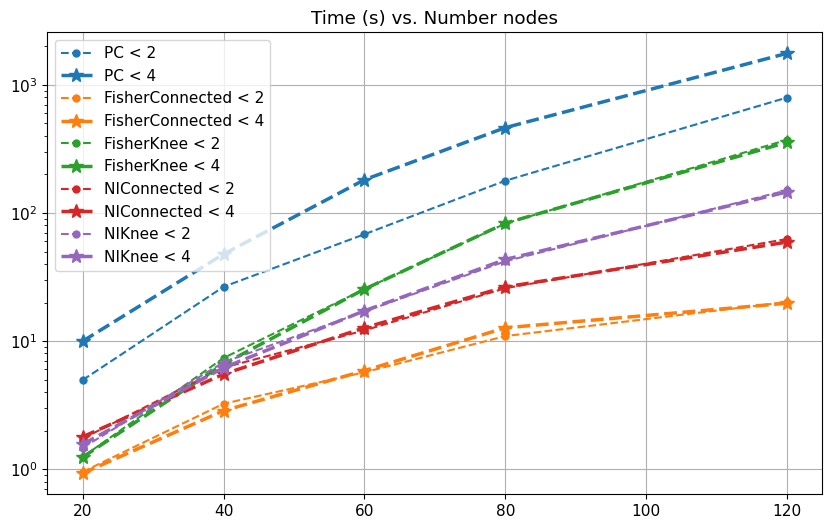

In [6]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee'] 
columns=[2,8,14,20,26]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.yscale("log")
pl.title("Time (s) vs. Number nodes")
pl.grid(),pl.legend()
pl.show()

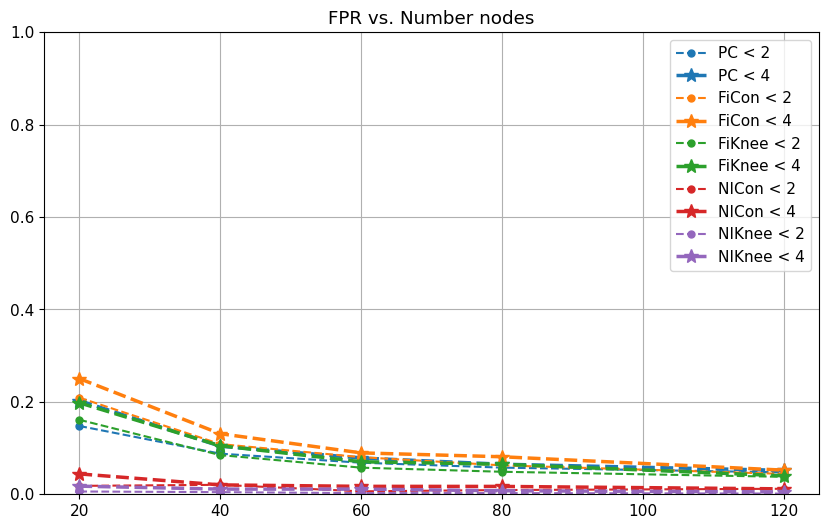

In [82]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee']
columns=[3,9,15,21,27]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.title("FPR vs. Number nodes")
pl.ylim(0,1)
pl.grid(),pl.legend()
pl.show()

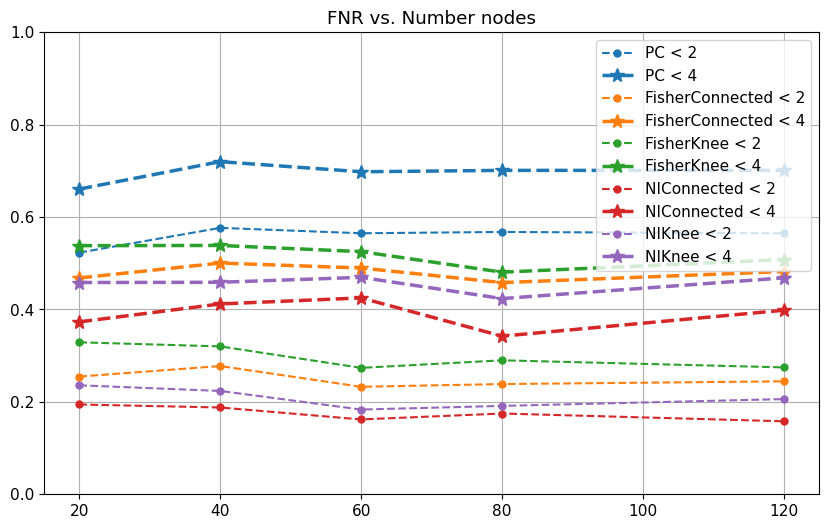

In [7]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee'] 
columns=[4,10,16,22,28]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.title("FNR vs. Number nodes")
pl.ylim(0,1)
pl.grid(),pl.legend()
pl.show()

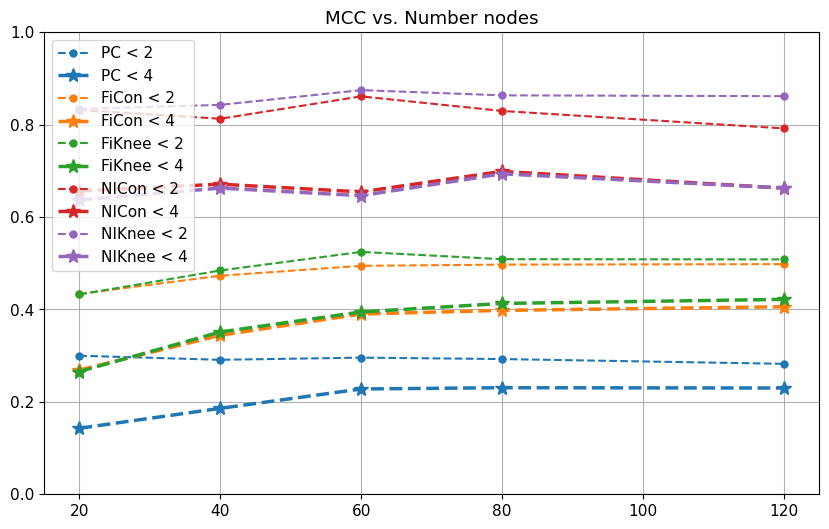

In [80]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
columns=[5,11,17,23,29]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.title("MCC vs. Number nodes")
pl.ylim(0,1)
pl.grid(),pl.legend()
pl.show()